# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme()

# encode
from sklearn.preprocessing import LabelEncoder

# machine learning
from sklearn.ensemble import RandomForestClassifier

# datetime
from datetime import datetime

# xử lý chuỗi
import re

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [ ]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Viewing data

In [ ]:
# load dataset
file_path = "/content/drive/MyDrive/0003. FTU SUBJECTS/010. PHÂN TÍCH DỮ LIỆU/04. CUSTOMER SEGMENTATION PROJECT/01. MATERIAL/02. DATASET GỐC/Raw_data.xlsx - CustomerAddress.csv"
df = pd.read_csv(file_path)

In [ ]:
display(df.head())

,customer_id,address,postcode,state,country,property_valuation
0,1,060 Morning Avenue,2016,New South Wales,Australia,10
1,2,6 Meadow Vale Court,2153,New South Wales,Australia,10
2,4,0 Holy Cross Court,4211,QLD,Australia,9
3,5,17979 Del Mar Point,2448,New South Wales,Australia,4
4,6,9 Oakridge Court,3216,VIC,Australia,9


---

# Inspect Dataset

---

## Infomation

In [ ]:
# Hiển thị thông tin cơ bản về dữ liệu
print("Thông tin tổng quan về dataset:")
print(df.info())

Thông tin tổng quan về dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         3999 non-null   int64 
 1   address             3999 non-null   object
 2   postcode            3999 non-null   int64 
 3   state               3999 non-null   object
 4   country             3999 non-null   object
 5   property_valuation  3999 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 187.6+ KB
None


---

### Mô tả ngắn gọn thông tin dữ liệu

Dữ liệu chứa thông tin về địa chỉ và thông tin liên quan của khách hàng, với **3999 bản ghi** và **6 cột**. Dưới đây là mô tả chi tiết từng cột:

| Tên cột              | Mô tả                                      | Số giá trị không null | Kiểu dữ liệu |
|----------------------|--------------------------------------------|-----------------------|--------------|
| `customer_id`        | ID duy nhất của khách hàng                 | 3999                  | `int64`      |
| `address`            | Địa chỉ của khách hàng                     | 3999                  | `object`     |
| `postcode`           | Mã bưu chính                               | 3999                  | `int64`      |
| `state`              | Bang hoặc khu vực nơi khách hàng sinh sống | 3999                  | `object`     |
| `country`            | Quốc gia của khách hàng                    | 3999                  | `object`     |
| `property_valuation` | Đánh giá tài sản của khách hàng            | 3999                  | `int64`      |

---

## Tổng quan về kiểu dữ liệu

- **2 cột kiểu `int64`**: `customer_id`, `postcode`.
- **3 cột kiểu `object`**: `address`, `state`, `country`.
- **1 cột kiểu `int64`**: `property_valuation`.

---

## Nhận xét thêm

- **Cột `state` cần được chuẩn hóa** để đảm bảo tính nhất quán (ví dụ: "New South Wales", "NSW", "New South Wale" đều được chuyển về "NSW").
- Một số `customer_id` từ bảng `CustomerDemographics` không xuất hiện trong bảng này, cần kiểm tra và điều chỉnh để đảm bảo tính đồng bộ giữa các bảng.
- Không có giá trị bị thiếu trong bất kỳ cột nào.

---

## Describe

In [ ]:
# Numerical
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
customer_id,3999.00,2003.99,1154.58,1.00,1004.50,2004.00,3003.50,4003.00
postcode,3999.00,2985.76,844.88,2000.00,2200.00,2768.00,3750.00,4883.00
property_valuation,3999.00,7.51,2.82,1.00,6.00,8.00,10.00,12.00


---

### Nhận xét chung về dữ liệu số

- **Không có giá trị bị thiếu**: Tất cả các cột đều có **3999 giá trị**, đảm bảo tính toàn vẹn của dữ liệu.
  
- **Phân phối dữ liệu**:
  - `customer_id` và `property_valuation` có phân phối khá đồng đều.
  - `postcode` có sự biến thiên lớn hơn, phản ánh sự đa dạng về địa lý.

- **Không có outliers nghiêm trọng**: Các giá trị **min**, **max**, và **quartiles** đều hợp lý, không có dấu hiệu của dữ liệu bất thường vượt ngoài phạm vi mong đợi.

---

## Ý nghĩa thực tế

- **`customer_id`**: Đóng vai trò là định danh duy nhất, không mang ý nghĩa phân tích sâu.
- **`postcode`**: Cung cấp thông tin địa lý, có thể sử dụng để phân tích theo khu vực.
- **`property_valuation`**: Là một chỉ số quan trọng để đánh giá tiềm năng tài chính của khách hàng.

---

## Khuyến nghị phân tích tiếp theo

1. **Sử dụng `postcode`**:
   - Phân tích phân bố địa lý của khách hàng.
   - Xác định các khu vực trọng điểm để tập trung chiến lược kinh doanh.

2. **Kết hợp `property_valuation` với các thuộc tính khác**:
   - Ví dụ: Kết hợp với `wealth_segment` để phân loại khách hàng thành các nhóm có giá trị tương đồng.

3. **Kiểm tra mối tương quan giữa `property_valuation` và hành vi mua sắm**:
   - Ví dụ: Số lần mua xe đạp trong 3 năm qua (`past_3_years_bike_related_purchases`) để hiểu rõ hơn về mối liên hệ giữa tài sản và hành vi tiêu dùng.

---

In [ ]:
# Object
display(df.describe(include='object').T)

,count,unique,top,freq
address,3999,3996,3 Mariners Cove Terrace,2
state,3999,5,NSW,2054
country,3999,1,Australia,3999


---

### Nhận xét chung dữ liệu chữ

- **Không có giá trị bị thiếu**: Tất cả các cột đều có **3999 giá trị**, đảm bảo tính toàn vẹn của dữ liệu.

---

## Đặc điểm nổi bật

- **Địa chỉ (`address`)**:
  - Chủ yếu là duy nhất, phản ánh tính cá nhân hóa cao.
  
- **Bang (`state`)**:
  - Có sự phân bố không đồng đều, với **NSW** chiếm đa số.
  
- **Quốc gia (`country`)**:
  - Chỉ có một giá trị duy nhất ("Australia"), không cần xử lý thêm.

---

## Khuyến nghị

1. **Chuẩn hóa tên bang trong cột `state`**:
   - Đảm bảo nhất quán bằng cách chuyển các tên đầy đủ thành dạng viết tắt (ví dụ: chuyển "New South Wales" thành "NSW").

2. **Kiểm tra các địa chỉ trùng lặp trong cột `address`**:
   - Xác định nguyên nhân của các địa chỉ trùng lặp và xử lý nếu cần để đảm bảo tính chính xác của dữ liệu.

---

# Data Cleaning

## Tạo dataframe copy

In [ ]:
df_clean = df.copy()

---

## Chuẩn hóa dữ liệu cột state
- Tạo danh sách ánh xạ giữa tên đầy đủ và tên viết tắt.
- Chuyển đổi tất cả các giá trị trong cột state về dạng viết tắt chuẩn.

In [ ]:
df_clean['state'].unique()

array(['New South Wales', 'QLD', 'VIC', 'NSW', 'Victoria'], dtype=object)

In [ ]:
df_clean['state'].value_counts()

,count
state,
NSW,2054
VIC,939
QLD,838
New South Wales,86
Victoria,82


<Axes: xlabel='state', ylabel='count'>

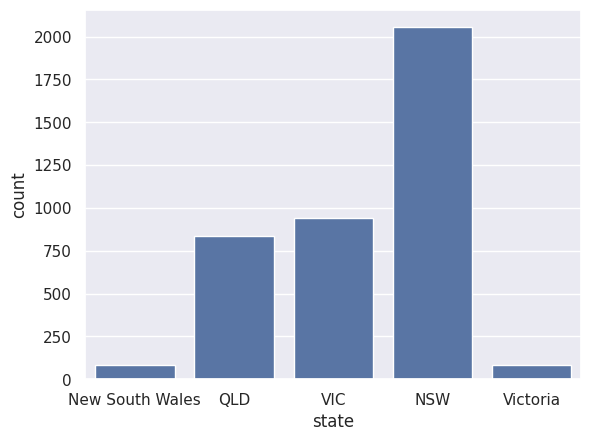

In [ ]:
sns.countplot(data=df_clean, x='state')

In [ ]:
# Danh sách ánh xạ giữa tên đầy đủ và tên viết tắt
state_mapping = {
    'New South Wales': 'NSW',
    'Victoria': 'VIC',
    'NSW': 'NSW',
    'VIC': 'VIC',
    'QLD': 'QLD'
}

# Áp dụng ánh xạ để chuẩn hóa cột state
df_clean['state'] = df_clean['state'].map(state_mapping)

<Axes: xlabel='state', ylabel='count'>

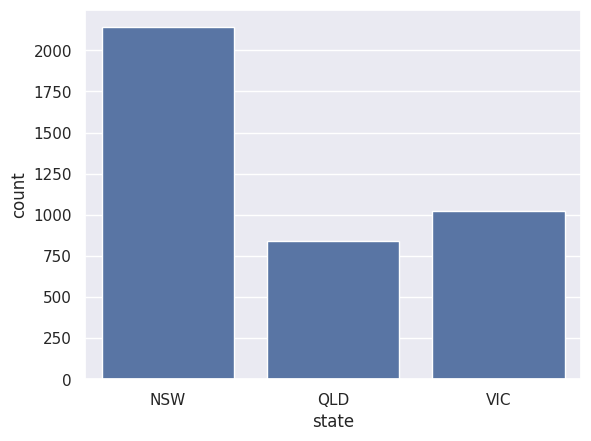

In [ ]:
sns.countplot(data=df_clean, x='state')

## Kiểm tra và xử lý các địa chỉ trùng lặp trong cột address
- Xác định các địa chỉ trùng lặp.
- Phân tích nguyên nhân và xử lý nếu cần.

In [ ]:
# Nhóm các địa chỉ trùng lặp và hiển thị danh sách customer_id tương ứng
duplicate_addresses_grouped = (
    df_clean[df_clean.duplicated(subset='address', keep=False)]  # Lọc ra các địa chỉ trùng lặp
    .groupby('address')['customer_id']  # Nhóm theo địa chỉ và lấy customer_id
    .apply(list)  # Chuyển danh sách customer_id thành list
    .reset_index()  # Reset index để tạo DataFrame mới
)

# Hiển thị kết quả
if not duplicate_addresses_grouped.empty:
    print("Các địa chỉ trùng lặp và danh sách khách hàng:")
    display(duplicate_addresses_grouped)
else:
    print("Không có địa chỉ trùng lặp.")

Các địa chỉ trùng lặp và danh sách khách hàng:


,address,customer_id
0,3 Mariners Cove Terrace,"[2333, 2985]"
1,3 Talisman Place,"[737, 2475]"
2,64 Macpherson Junction,"[2320, 3540]"


- Dữ liệu address trùng lặp là hợp lý bởi những khách hàng có id trên có thể chung nhà hoặc chung cư

---

## Đồng bộ dữ liệu với bảng CustomerDemographics
- So sánh danh sách customer_id giữa hai bảng.
- Điều tra và xử lý các ID bị thiếu.

In [ ]:
# load CustomerDemographics
file_path = "/content/drive/MyDrive/0003. FTU SUBJECTS/010. PHÂN TÍCH DỮ LIỆU/04. CUSTOMER SEGMENTATION PROJECT/02. NOTEBOOK/01. CLEANING DATA/02. CLEANED DATASET/Cleaned_CustomerDemographic.csv"
customer_demographics = pd.read_csv(file_path)

In [ ]:
customer_demographics.head(3)

,customer_id,past_3_years_bike_related_purchases,tenure,Age,first_name,last_name,gender,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car
0,1,93,11.00,72,Laraine,Medendorp,Female,1953-10-12,Executive Secretary,Health,Mass Customer,N,Yes
1,2,81,16.00,45,Eli,Bockman,Male,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,Yes
2,3,61,15.00,71,Arlin,Dearle,Male,1954-01-20,Recruiting Manager,Property,Mass Customer,N,Yes


In [ ]:
# So sánh danh sách customer_id
missing_customer_ids = set(customer_demographics['customer_id']) - set(df_clean['customer_id'])

In [ ]:
if missing_customer_ids:
    print(f"Có {len(missing_customer_ids)} customer_id bị thiếu trong bảng CustomerAddress so với customer_demographics:")
    print(missing_customer_ids)
else:
    print("Không có customer_id bị thiếu.")

Có 4 customer_id bị thiếu trong bảng CustomerAddress so với customer_demographics:
{10, 3, 22, 23}


In [ ]:
extra_customer_ids = set(df_clean['customer_id']) - set(customer_demographics['customer_id'])

In [ ]:
if extra_customer_ids:
    print(f"Có {len(extra_customer_ids)} customer_id thừa trong bảng CustomerAddress so với bảng customer_demographics:")
    print(extra_customer_ids)
else:
    print("Không có customer_id thừa.")

Có 4 customer_id thừa trong bảng CustomerAddress so với bảng customer_demographics:
{4002, 4001, 34, 4003}


## So sánh data clean và data gốc

In [ ]:
percentage = len(df_clean) / len(df) * 100
print(f'Data clean chiếm  {percentage:.2f}% so với data gốc')

Data clean chiếm  100.00% so với data gốc


## Sắp xếp lại các cột

In [ ]:
print(f'Số cột của data gốc: {len(df.columns)}')
print(f'Số cột của data clean: {len(df_clean.columns)}')

Số cột của data gốc: 6
Số cột của data clean: 6


In [ ]:
# Lấy danh sách các cột kiểu object
object_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

# Lấy danh sách các cột kiểu numeric
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Sắp xếp lại thứ tự cột: Numeric -> Object
df_clean = df_clean[numeric_columns + object_columns]

# Kiểm tra số cột
print(f'Số cột của data clean sau khi sắp xếp cột : {len(df_clean.columns)}')

Số cột của data clean sau khi sắp xếp cột : 6


In [ ]:
df_clean.head(3)

,customer_id,postcode,property_valuation,address,state,country
0,1,2016,10,060 Morning Avenue,NSW,Australia
1,2,2153,10,6 Meadow Vale Court,NSW,Australia
2,4,4211,9,0 Holy Cross Court,QLD,Australia


---

# Lưu data đã được làm sạch

In [ ]:
cleaned_file_path = "Cleaned_CustomerAddress.csv"
df_clean.to_csv(cleaned_file_path, index=False)

print("Dữ liệu đã được làm sạch và lưu vào file:", cleaned_file_path)

Dữ liệu đã được làm sạch và lưu vào file: Cleaned_CustomerAddress.csv


https://www.perplexity.ai/page/ai-generated-images-tools-prom-efxu3L04SpufSVPD532HQg